# 3D GridWorld Navigation — Q-Learning y DQN

**Autor**: Abraham Rodriguez

**Materia**: Aprendizaje por Refuerzo I

**Problema:** Un agente debe navegar desde una posición inicial hasta un objetivo en un espacio tridimensional (grilla 3D) que contiene obstáculos. El eje Z representa pisos/alturas, y el agente puede moverse en las 6 direcciones cardinales del espacio 3D.

**Técnicas aplicada:** 
- Q-Learning 
- DQN


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict, deque
from typing import Optional
import random
import gymnasium as gym
from gymnasium import spaces

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. Entorno: GridWorld3D

### Definición del problema

El entorno es una grilla 3D de dimensiones `W × H × D` (ancho × alto × profundidad).

- **Estado:** tupla `(x, y, z)` — posición actual del agente
- **Acciones:** 6 movimientos cardinales
  - `0`: +x (este), `1`: −x (oeste)
  - `2`: +y (norte), `3`: −y (sur)
  - `4`: +z (subir), `5`: −z (bajar)
- **Obstáculos:** celdas bloqueadas (densidad controlada por `obstacle_density`)
- **Recompensas:**
  - `−1` por cada paso (penalidad temporal)
  - `−2` al chocar con pared o límite (el agente no se mueve)
  - `+shaping_scale × Δdistancia` reward shaping por distancia Manhattan al objetivo
  - `+100` al alcanzar el objetivo
- **Fin del episodio:** alcanzar el objetivo o superar `max_steps`

### Generación del mundo y conectividad garantizada

Se colocan obstáculos aleatoriamente. Luego un **BFS** verifica que existe camino del inicio al objetivo. Si no existe, `_carve_corridor()` talla un corredor directo. Esto garantiza que el problema siempre es resoluble.

### Reward Shaping basado en distancia Manhattan

$$r_{\text{shaping}} = \alpha_s \cdot \left(\text{dist}(s, \text{goal}) - \text{dist}(s', \text{goal})\right)$$

Positivo al acercarse al objetivo, negativo al alejarse. No altera la política óptima (Ng et al., 1999).

In [3]:
class GridWorld3D(gym.Env):
    """
    3D grid navigation environment (Gymnasium-compatible).
    Agent navigates from start to goal avoiding scattered obstacles in a W x H x D grid.
    Connectivity is guaranteed: BFS check after generation, corridor carved if unreachable.
    """

    metadata = {"render_modes": ["ansi"]}

    ACTION_DELTAS = {
        0: ( 1,  0,  0),  # +X east
        1: (-1,  0,  0),  # -X west
        2: ( 0,  1,  0),  # +Y north
        3: ( 0, -1,  0),  # -Y south
        4: ( 0,  0,  1),  # +Z up
        5: ( 0,  0, -1),  # -Z down
    }
    N_ACTIONS = 6
    ACTION_NAMES = ["+X", "-X", "+Y", "-Y", "+Z", "-Z"]

    def __init__(
        self,
        width: int = 6,
        height: int = 6,
        depth: int = 3,
        start: tuple = (0, 0, 0),
        goal: tuple = (5, 5, 2),
        obstacle_density: float = 0.10,
        shaping_scale: float = 0.5,
        max_steps: int = 300,
        seed: Optional[int] = None,
        render_mode: Optional[str] = None,
    ):
        super().__init__()
        self.W = width
        self.H = height
        self.D = depth
        self.start = start
        self.goal = goal
        self.max_steps = max_steps
        self.shaping_scale = shaping_scale
        self.render_mode = render_mode
        self._obstacle_density = obstacle_density
        self._rng = np.random.default_rng(seed)

        self.action_space = spaces.Discrete(self.N_ACTIONS)
        self.observation_space = spaces.MultiDiscrete([self.W, self.H, self.D])

        self.obstacles: set[tuple] = set()
        self._build_world()

        self._state = self.start
        self._steps = 0

    # ------------------------------------------------------------------
    # World generation
    # ------------------------------------------------------------------

    def _build_world(self):
        """Scatter random obstacles, then guarantee start→goal connectivity."""
        self.obstacles = set()
        self._scatter_obstacles()
        self.obstacles.discard(self.start)
        self.obstacles.discard(self.goal)
        if not self._bfs_connected(self.start, self.goal):
            self._carve_corridor()

    def _scatter_obstacles(self):
        n = int(self.W * self.H * self.D * self._obstacle_density)
        added, attempts = 0, 0
        while added < n and attempts < n * 20:
            cell = (
                int(self._rng.integers(0, self.W)),
                int(self._rng.integers(0, self.H)),
                int(self._rng.integers(0, self.D)),
            )
            if cell != self.start and cell != self.goal and cell not in self.obstacles:
                self.obstacles.add(cell)
                added += 1
            attempts += 1

    def _bfs_connected(self, src: tuple, dst: tuple) -> bool:
        """BFS reachability check from src to dst."""
        visited = {src}
        queue = deque([src])
        while queue:
            x, y, z = queue.popleft()
            if (x, y, z) == dst:
                return True
            for dx, dy, dz in self.ACTION_DELTAS.values():
                nb = (x + dx, y + dy, z + dz)
                if self._is_valid(*nb) and nb not in visited:
                    visited.add(nb)
                    queue.append(nb)
        return False

    def _carve_corridor(self):
        """Remove obstacles along an L-shaped axis-aligned path start→goal."""
        sx, sy, sz = self.start
        gx, gy, gz = self.goal
        x, y, z = sx, sy, sz
        while x != gx:
            x += 1 if gx > x else -1
            self.obstacles.discard((x, y, z))
        while y != gy:
            y += 1 if gy > y else -1
            self.obstacles.discard((x, y, z))
        while z != gz:
            z += 1 if gz > z else -1
            self.obstacles.discard((x, y, z))

    # ------------------------------------------------------------------
    # Gymnasium interface
    # ------------------------------------------------------------------

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._state = self.start
        self._steps = 0
        return np.array(self._state, dtype=np.int32), {}

    def step(self, action: int):
        dx, dy, dz = self.ACTION_DELTAS[action]
        x, y, z = self._state
        nx, ny, nz = x + dx, y + dy, z + dz

        prev_dist = self._manhattan(self._state)

        if self._is_valid(nx, ny, nz):
            self._state = (nx, ny, nz)
            curr_dist = self._manhattan(self._state)
            reward = -1.0 + self.shaping_scale * (prev_dist - curr_dist)
        else:
            reward = -2.0  # wall/boundary penalty, agent stays put

        self._steps += 1
        terminated = self._state == self.goal
        truncated  = self._steps >= self.max_steps

        if terminated:
            reward = 100.0

        return (
            np.array(self._state, dtype=np.int32),
            reward,
            terminated,
            truncated,
            {"steps": self._steps, "reached_goal": terminated},
        )

    def _is_valid(self, x, y, z) -> bool:
        return (
            0 <= x < self.W and
            0 <= y < self.H and
            0 <= z < self.D and
            (x, y, z) not in self.obstacles
        )

    def _manhattan(self, state: tuple) -> int:
        return sum(abs(a - b) for a, b in zip(state, self.goal))

    def get_state(self) -> tuple:
        return self._state

    def state_to_tuple(self, obs) -> tuple:
        return tuple(int(v) for v in obs)

    @property
    def n_states(self) -> int:
        return self.W * self.H * self.D

    @property
    def obstacle_count(self) -> int:
        return len(self.obstacles)


# Sanity check
env = GridWorld3D(seed=SEED)
obs, _ = env.reset()
print(f"Grid size         : {env.W} x {env.H} x {env.D}  ({env.n_states} celdas)")
print(f"Obstáculos        : {env.obstacle_count} ({env.obstacle_count/env.n_states*100:.1f}%)")
print(f"Start → Goal      : {env.start} → {env.goal}")
print(f"Camino alcanzable : {env._bfs_connected(env.start, env.goal)}")
print(f"Manhattan dist    : {env._manhattan(env.start)}")

Grid size         : 6 x 6 x 3  (108 celdas)
Obstáculos        : 10 (9.3%)
Start → Goal      : (0, 0, 0) → (5, 5, 2)
Camino alcanzable : True
Manhattan dist    : 12


## 2. Visualización del Mundo 3D

Antes de entrenar, visualizamos la estructura del entorno: obstáculos, inicio y objetivo.

/var/folders/bf/p7_3d4ln30l_vsv0f_41b4sw0000gn/T/ipykernel_5900/416895561.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


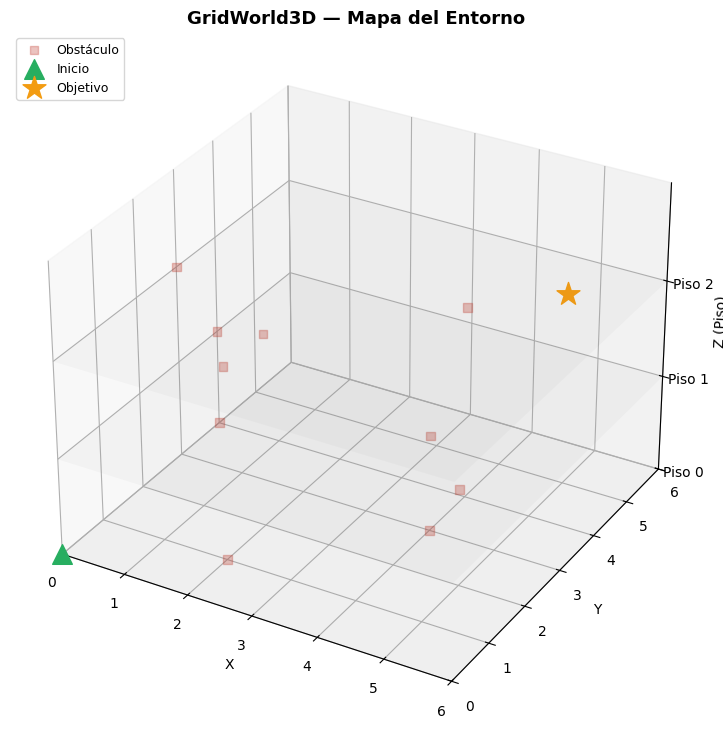

In [4]:
def plot_world(env: GridWorld3D, path: list = None, title: str = "GridWorld3D — Mapa del Entorno"):
    """Render the 3D grid, obstacles, start, goal and optionally a learned path."""
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    # Obstacles
    if env.obstacles:
        ox, oy, oz = zip(*env.obstacles)
        ax.scatter(ox, oy, oz, c="#c0392b", marker="s", s=40, alpha=0.3, label="Obstáculo")

    # Start and goal
    ax.scatter(*env.start, c="#27ae60", marker="^", s=200, zorder=5, label="Inicio")
    ax.scatter(*env.goal,  c="#f39c12", marker="*", s=300, zorder=5, label="Objetivo")

    # Learned path
    if path:
        px, py, pz = zip(*path)
        ax.plot(px, py, pz, c="#2980b9", linewidth=2.5, zorder=6, label="Camino aprendido")
        ax.scatter(px, py, pz, c="#2980b9", s=20, alpha=0.6, zorder=7)

    # Transparent floor planes
    for z in range(env.D):
        xx = np.array([[0, env.W], [0, env.W]])
        yy = np.array([[0, 0], [env.H, env.H]])
        zz = np.full_like(xx, z, dtype=float)
        ax.plot_surface(xx, yy, zz, alpha=0.04, color="gray")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (Piso)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.set_xlim(0, env.W)
    ax.set_ylim(0, env.H)
    ax.set_zlim(0, env.D)
    ax.set_zticks(range(env.D))
    ax.set_zticklabels([f"Piso {z}" for z in range(env.D)])
    plt.tight_layout()
    plt.show()


env = GridWorld3D(seed=SEED)
plot_world(env)

## 3. Agente Q-Learning

### Algoritmo

Q-Learning es un método off-policy de Temporal Difference (TD). La regla de actualización es:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

### Política ε-greedy con decaimiento multiplicativo

$$\varepsilon_{t+1} = \max\left(\varepsilon_{\min},\ \varepsilon_t \cdot (1 - \lambda)\right)$$

Donde `λ = epsilon_decay`. El decaimiento multiplicativo garantiza convergencia suave sin requerir conocimiento de `N_EPISODES` por adelantado, y el parámetro `epsilon_decay` controla directamente la velocidad de decaimiento.

In [ ]:
class QLearningAgent:
    """
    Tabular Q-Learning agent with epsilon-greedy exploration and multiplicative decay.
    Q-table backed by a defaultdict — unseen (state, action) pairs initialize to zeros.
    """

    def __init__(
        self,
        n_actions: int,
        alpha: float = 0.2,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_min: float = 0.05,
        epsilon_decay: float = 0.001,
    ):
        self.n_actions   = n_actions
        self.alpha       = alpha
        self.gamma       = gamma
        self.epsilon     = epsilon_start
        self.epsilon_min = epsilon_min
        self._decay_rate = 1.0 - epsilon_decay

        self.Q: dict[tuple, np.ndarray] = defaultdict(
            lambda: np.zeros(self.n_actions, dtype=np.float64)
        )
        self.epsilon_history: list[float] = []

    def select_action(self, state: tuple) -> int:
        """Epsilon-greedy: explore randomly or exploit learned Q-values."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def greedy_action(self, state: tuple) -> int:
        """Pure greedy — used during evaluation (zero exploration)."""
        return int(np.argmax(self.Q[state]))

    def update(self, state: tuple, action: int, reward: float, next_state: tuple, done: bool):
        """Q-Learning (off-policy TD) update."""
        current_q = self.Q[state][action]
        target    = reward if done else reward + self.gamma * np.max(self.Q[next_state])
        self.Q[state][action] += self.alpha * (target - current_q)

    def decay_epsilon(self):
        """Multiplicative decay: epsilon *= (1 - epsilon_decay), floored at epsilon_min."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self._decay_rate)
        self.epsilon_history.append(self.epsilon)

    @property
    def n_states_visited(self) -> int:
        return len(self.Q)

agent_test = QLearningAgent(n_actions=6)
checkpoints = [0, 500, 1000, 3000, 5000, 8000]
ep = 0
for target in checkpoints:
    while ep < target:
        agent_test.decay_epsilon()
        ep += 1
    print(f"  ε en episodio {ep:>5}: {agent_test.epsilon:.4f}")

  ε en episodio     0: 1.0000
  ε en episodio   500: 0.6064
  ε en episodio  1000: 0.3677
  ε en episodio  3000: 0.0500
  ε en episodio  5000: 0.0500
  ε en episodio  8000: 0.0500


## 6. Entrenamiento

| Parámetro | Valor | Descripción |
|---|---|---|
| `n_episodes` | 8000 | Episodios totales |
| `alpha` | 0.2 | Tasa de aprendizaje |
| `gamma` | 0.99 | Factor de descuento |
| `epsilon_decay` | 0.001 | ε alcanza `epsilon_min` (~0.05) en ep ~2990 |
| `max_steps` | 300 | Pasos máximos por episodio (grilla 6×6×3) |
| `obstacle_density` | 10% | Mundo navegable con obstáculos moderados |
| `shaping_scale` | 0.5 | Peso del reward shaping por distancia Manhattan |

In [6]:
N_EPISODES    = 8000
ALPHA         = 0.2
GAMMA         = 0.99
EPSILON_START = 1.0
EPSILON_MIN   = 0.05
EPSILON_DECAY = 0.001
MAX_STEPS     = 300
LOG_EVERY     = 1000

env = GridWorld3D(
    width=8, height=8, depth=8,
    start=(0, 0, 0), goal=(7, 7, 4),
    obstacle_density=0.2,
    shaping_scale=0.5,
    max_steps=MAX_STEPS,
    seed=SEED,
)

agent = QLearningAgent(
    n_actions=env.action_space.n,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
)

print(f"Obstáculos        : {env.obstacle_count} ({env.obstacle_count/env.n_states*100:.1f}%)")
print(f"Camino alcanzable : {env._bfs_connected(env.start, env.goal)}")
print(f"Manhattan dist    : {env._manhattan(env.start)}")
print(f"ε alcanza mínimo en aprox. ep: {int(np.log(EPSILON_MIN / EPSILON_START) / np.log(1 - EPSILON_DECAY))}\n")

episode_rewards: list[float] = []
episode_lengths: list[int]   = []
success_flags:   list[bool]  = []

for episode in range(1, N_EPISODES + 1):
    obs, _ = env.reset()
    state  = env.state_to_tuple(obs)
    total_reward = 0.0
    step = 0

    for step in range(MAX_STEPS):
        action = agent.select_action(state)
        obs_next, reward, terminated, truncated, info = env.step(action)
        next_state = env.state_to_tuple(obs_next)

        agent.update(state, action, reward, next_state, terminated or truncated)

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    agent.decay_epsilon()
    episode_rewards.append(total_reward)
    episode_lengths.append(step + 1)
    success_flags.append(info["reached_goal"])

    if episode % LOG_EVERY == 0:
        w = 500
        avg_r  = np.mean(episode_rewards[-w:])
        succ_r = np.mean(success_flags[-w:]) * 100
        print(
            f"Ep {episode:>5} | ε={agent.epsilon:.4f} | "
            f"Reward medio ({w} ep): {avg_r:>7.2f} | "
            f"Éxito: {succ_r:>5.1f}% | "
            f"Estados Q: {agent.n_states_visited}"
        )

print(f"\nEntrenamiento finalizado.")
print(f"Tasa de éxito final (últimos 500 ep): {np.mean(success_flags[-500:]) * 100:.1f}%")

Obstáculos        : 102 (19.9%)
Camino alcanzable : True
Manhattan dist    : 18
ε alcanza mínimo en aprox. ep: 2994

Ep  1000 | ε=0.3677 | Reward medio (500 ep):   66.92 | Éxito: 100.0% | Estados Q: 409
Ep  2000 | ε=0.1352 | Reward medio (500 ep):   86.37 | Éxito: 100.0% | Estados Q: 409
Ep  3000 | ε=0.0500 | Reward medio (500 ep):   89.74 | Éxito: 100.0% | Estados Q: 409
Ep  4000 | ε=0.0500 | Reward medio (500 ep):   90.26 | Éxito: 100.0% | Estados Q: 409
Ep  5000 | ε=0.0500 | Reward medio (500 ep):   90.33 | Éxito: 100.0% | Estados Q: 409
Ep  6000 | ε=0.0500 | Reward medio (500 ep):   90.18 | Éxito: 100.0% | Estados Q: 409
Ep  7000 | ε=0.0500 | Reward medio (500 ep):   90.26 | Éxito: 100.0% | Estados Q: 409
Ep  8000 | ε=0.0500 | Reward medio (500 ep):   90.31 | Éxito: 100.0% | Estados Q: 409

Entrenamiento finalizado.
Tasa de éxito final (últimos 500 ep): 100.0%


## 4. Gráfico de Convergencia

Se grafican la recompensa por episodio con **media móvil**, la longitud del episodio y el decaimiento de ε. Las tres curvas juntas permiten correlacionar la exploración con el aprendizaje.

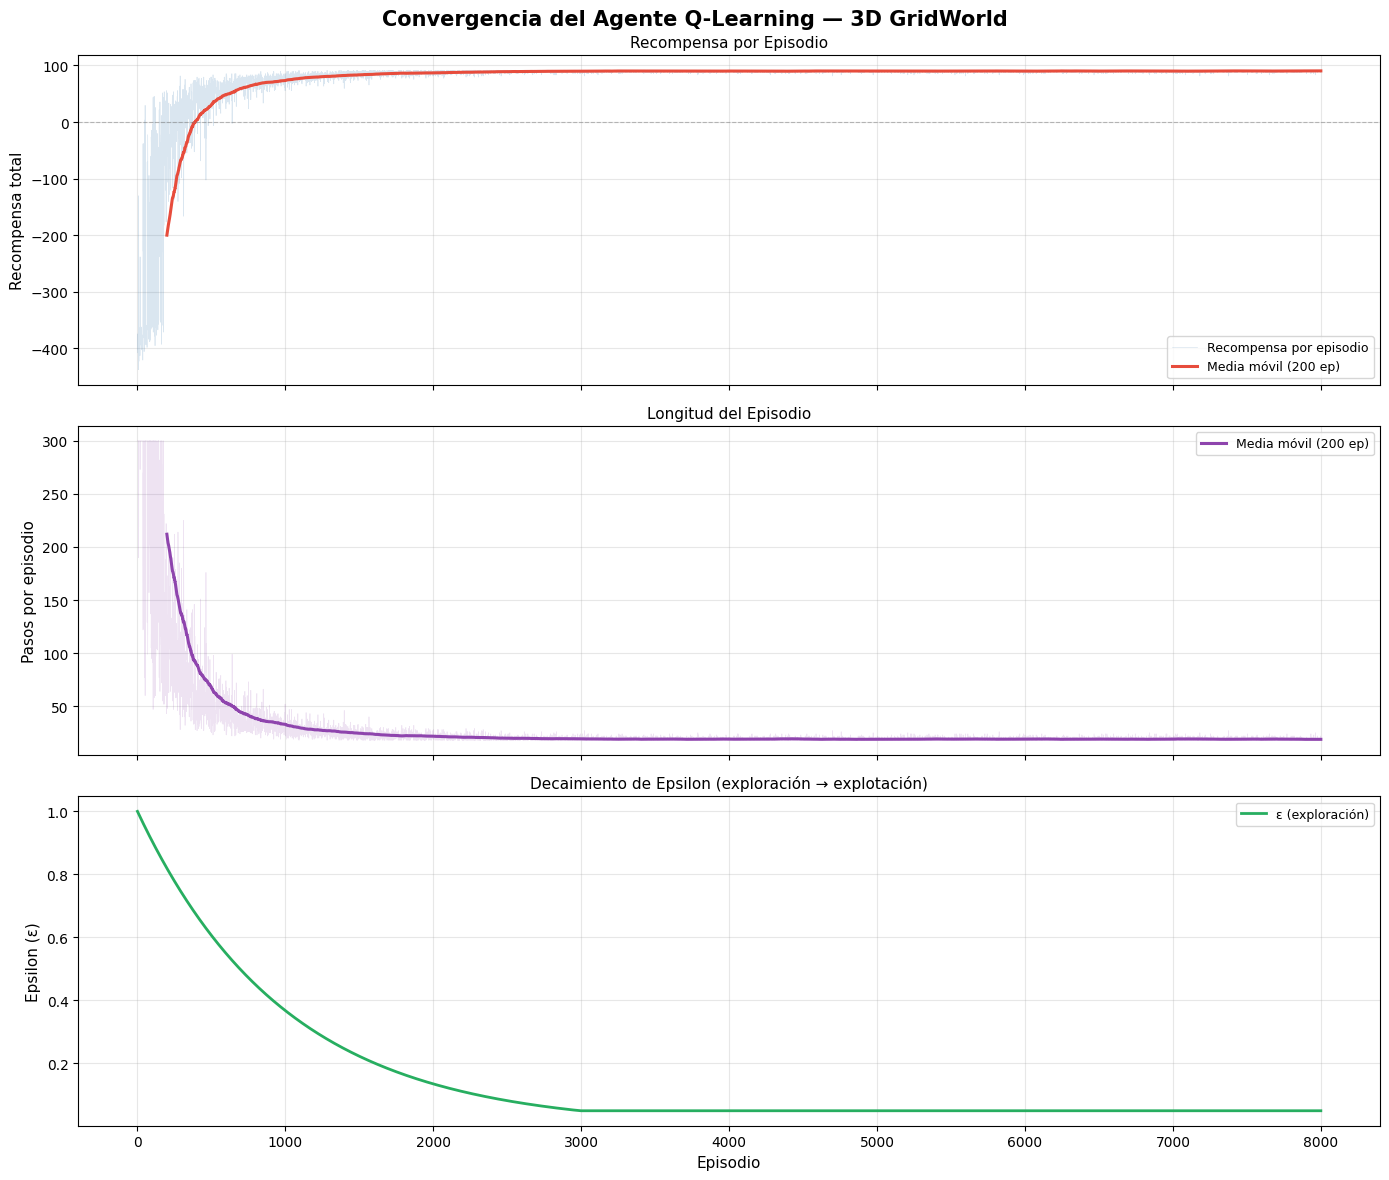

Guardado: convergence.png


In [7]:
def moving_average(data: list, window: int) -> np.ndarray:
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode="valid")


WINDOW = 200
episodes_axis = np.arange(1, N_EPISODES + 1)
ma_rewards    = moving_average(episode_rewards, WINDOW)
ma_lengths    = moving_average(episode_lengths, WINDOW)
ma_axis       = np.arange(WINDOW, N_EPISODES + 1)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Convergencia del Agente Q-Learning — 3D GridWorld", fontsize=15, fontweight="bold")

# Reward per episode
ax1 = axes[0]
ax1.plot(episodes_axis, episode_rewards, alpha=0.2, color="steelblue", linewidth=0.5, label="Recompensa por episodio")
ax1.plot(ma_axis, ma_rewards, color="#e74c3c", linewidth=2.2, label=f"Media móvil ({WINDOW} ep)")
ax1.axhline(y=0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.set_ylabel("Recompensa total", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_title("Recompensa por Episodio", fontsize=11)

# Episode length
ax2 = axes[1]
ax2.plot(episodes_axis, episode_lengths, alpha=0.15, color="#8e44ad", linewidth=0.5)
ax2.plot(ma_axis, ma_lengths, color="#8e44ad", linewidth=2.2, label=f"Media móvil ({WINDOW} ep)")
ax2.set_ylabel("Pasos por episodio", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_title("Longitud del Episodio", fontsize=11)

# Epsilon decay
ax3 = axes[2]
ax3.plot(episodes_axis, agent.epsilon_history, color="#27ae60", linewidth=2.0, label="ε (exploración)")
ax3.set_ylabel("Epsilon (ε)", fontsize=11)
ax3.set_xlabel("Episodio", fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_title("Decaimiento de Epsilon (exploración → explotación)", fontsize=11)

plt.tight_layout()
plt.savefig("convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: convergence.png")

## 5. Tasa de Éxito por Ventana de Episodios

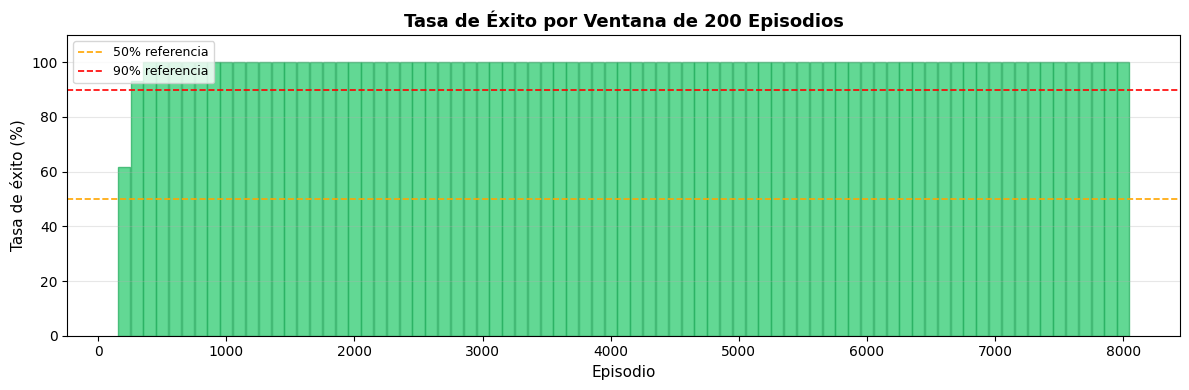

Guardado: success_rate.png


In [8]:
window = 200
step_size = window // 2
success_rate = [
    np.mean(success_flags[i: i + window]) * 100
    for i in range(0, len(success_flags) - window + 1, step_size)
]
sr_axis = np.arange(len(success_rate)) * step_size + window

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sr_axis, success_rate, width=step_size - 5, color="#2ecc71", alpha=0.75, edgecolor="#27ae60")
ax.axhline(y=50, color="orange", linestyle="--", linewidth=1.2, label="50% referencia")
ax.axhline(y=90, color="red",    linestyle="--", linewidth=1.2, label="90% referencia")
ax.set_xlabel("Episodio", fontsize=11)
ax.set_ylabel("Tasa de éxito (%)", fontsize=11)
ax.set_title(f"Tasa de Éxito por Ventana de {window} Episodios", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("success_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: success_rate.png")

## 6. Evaluación de la Política Aprendida

Ejecutamos el agente con política puramente greedy (ε = 0) sobre 50 episodios y registramos el mejor camino encontrado.

In [9]:
def evaluate_policy(env: GridWorld3D, agent: QLearningAgent, n_eval: int = 50) -> dict:
    """Run greedy episodes, collect stats and record the best successful path."""
    successes, steps_list, reward_list = [], [], []
    best_path   = None
    best_reward = -np.inf

    for _ in range(n_eval):
        obs, _ = env.reset()
        state = env.state_to_tuple(obs)
        path = [env.start]
        total_reward = 0.0
        done = False
        step = 0

        while not done and step < env.max_steps:
            action = agent.greedy_action(state)
            obs, reward, terminated, truncated, info = env.step(action)
            state = env.state_to_tuple(obs)
            path.append(env.get_state())
            total_reward += reward
            done = terminated or truncated
            step += 1

        successes.append(info["reached_goal"])
        steps_list.append(step)
        reward_list.append(total_reward)

        if info["reached_goal"] and total_reward > best_reward:
            best_reward = total_reward
            best_path   = path

    return {
        "success_rate": np.mean(successes) * 100,
        "avg_steps":    np.mean(steps_list),
        "avg_reward":   np.mean(reward_list),
        "best_path":    best_path,
        "best_reward":  best_reward,
    }


results = evaluate_policy(env, agent, n_eval=50)

print("=" * 52)
print("       EVALUACIÓN DE POLÍTICA GREEDY (50 eps)")
print("=" * 52)
print(f"  Tasa de éxito   : {results['success_rate']:.1f}%")
print(f"  Pasos promedio  : {results['avg_steps']:.1f}")
print(f"  Recompensa media: {results['avg_reward']:.2f}")
print(f"  Mejor recompensa: {results['best_reward']:.2f}")
if results['best_path']:
    print(f"  Longitud camino : {len(results['best_path'])} pasos")
print("=" * 52)

       EVALUACIÓN DE POLÍTICA GREEDY (50 eps)
  Tasa de éxito   : 100.0%
  Pasos promedio  : 18.0
  Recompensa media: 91.50
  Mejor recompensa: 91.50
  Longitud camino : 19 pasos


## 7. Visualización del Camino Aprendido en 3D

/var/folders/bf/p7_3d4ln30l_vsv0f_41b4sw0000gn/T/ipykernel_5900/416895561.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


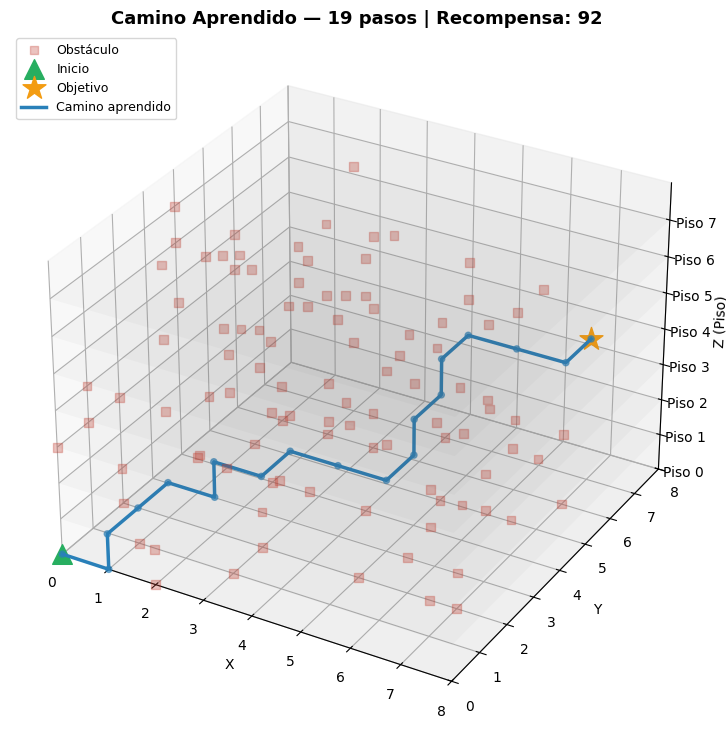

In [10]:
if results["best_path"]:
    plot_world(
        env,
        path=results["best_path"],
        title=(
            f"Camino Aprendido — {len(results['best_path'])} pasos | "
            f"Recompensa: {results['best_reward']:.0f}"
        ),
    )
else:
    print("El agente no encontró el objetivo en ningún episodio de evaluación.")
    plot_world(env)

## 8. Análisis de la Q-Table

### Mapa de calor: valor máximo Q por celda

Muestra cuánto "valor futuro esperado" aprendió el agente en cada celda de cada piso.

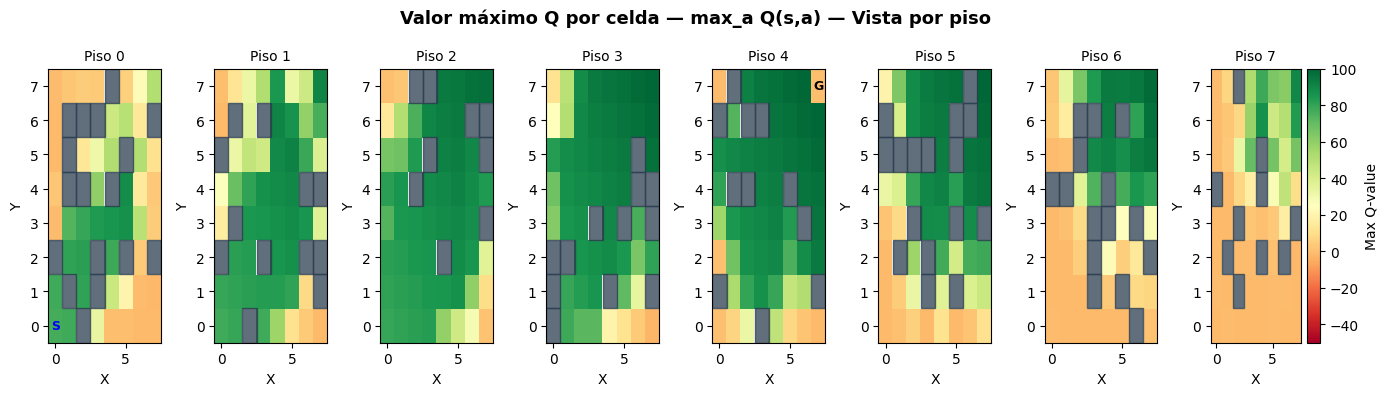

Guardado: qvalue_heatmap.png


In [11]:
fig, axes = plt.subplots(1, env.D, figsize=(14, 4))
fig.suptitle("Valor máximo Q por celda — max_a Q(s,a) — Vista por piso", fontsize=13, fontweight="bold")

for z in range(env.D):
    grid = np.full((env.H, env.W), np.nan)
    for x in range(env.W):
        for y in range(env.H):
            state = (x, y, z)
            if state not in env.obstacles:
                grid[y, x] = np.max(agent.Q[state]) if state in agent.Q else 0.0

    ax = axes[z]
    im = ax.imshow(grid, origin="lower", cmap="RdYlGn", vmin=-50, vmax=100, aspect="auto")
    ax.set_title(f"Piso {z}", fontsize=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    # Mark start/goal on their respective floors
    sx, sy, sz = env.start
    gx, gy, gz = env.goal
    if sz == z:
        ax.text(sx, sy, "S", ha="center", va="center", fontsize=9, fontweight="bold", color="blue")
    if gz == z:
        ax.text(gx, gy, "G", ha="center", va="center", fontsize=9, fontweight="bold", color="black")

    # Overlay obstacles
    for (ox, oy, oz) in env.obstacles:
        if oz == z:
            ax.add_patch(plt.Rectangle((ox - 0.5, oy - 0.5), 1, 1, color="#2c3e50", alpha=0.75))

plt.colorbar(im, ax=axes[-1], label="Max Q-value")
plt.tight_layout()
plt.savefig("qvalue_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: qvalue_heatmap.png")

### Mapa de política: acción óptima por celda

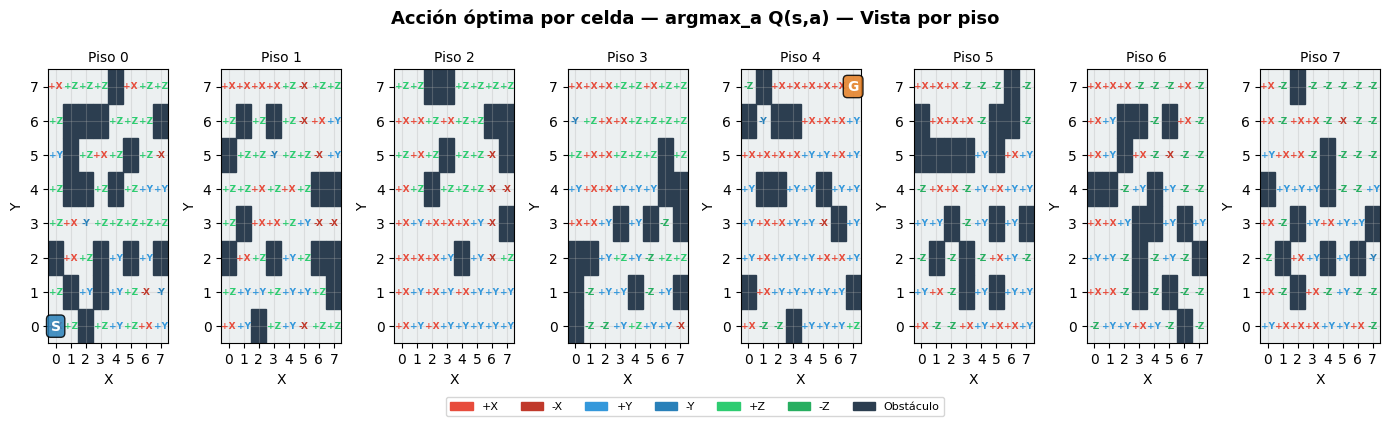

Guardado: policy_map.png


In [12]:
ACTION_SYMBOLS = ["+X", "-X", "+Y", "-Y", "+Z", "-Z"]
ACTION_COLORS  = ["#e74c3c", "#c0392b", "#3498db", "#2980b9", "#2ecc71", "#27ae60"]

fig, axes = plt.subplots(1, env.D, figsize=(14, 4))
fig.suptitle("Acción óptima por celda — argmax_a Q(s,a) — Vista por piso", fontsize=13, fontweight="bold")

for z in range(env.D):
    ax = axes[z]
    ax.set_xlim(-0.5, env.W - 0.5)
    ax.set_ylim(-0.5, env.H - 0.5)
    ax.set_title(f"Piso {z}", fontsize=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_facecolor("#ecf0f1")
    ax.set_xticks(range(env.W))
    ax.set_yticks(range(env.H))
    ax.grid(True, alpha=0.3)

    for x in range(env.W):
        for y in range(env.H):
            state = (x, y, z)
            if state in env.obstacles:
                ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color="#2c3e50"))
            elif state in agent.Q:
                a = int(np.argmax(agent.Q[state]))
                ax.text(x, y, ACTION_SYMBOLS[a], ha="center", va="center",
                        fontsize=6.5, color=ACTION_COLORS[a], fontweight="bold")

    # Mark start/goal
    sx, sy, sz = env.start
    gx, gy, gz = env.goal
    if sz == z:
        ax.text(sx, sy, "S", ha="center", va="center", fontsize=10, fontweight="bold",
                color="white", bbox=dict(boxstyle="round", facecolor="#2980b9", alpha=0.85))
    if gz == z:
        ax.text(gx, gy, "G", ha="center", va="center", fontsize=10, fontweight="bold",
                color="white", bbox=dict(boxstyle="round", facecolor="#e67e22", alpha=0.85))

legend_handles = [mpatches.Patch(color=c, label=s) for s, c in zip(ACTION_SYMBOLS, ACTION_COLORS)]
legend_handles.append(mpatches.Patch(color="#2c3e50", label="Obstáculo"))
fig.legend(handles=legend_handles, loc="lower center", ncol=7, fontsize=8, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("policy_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: policy_map.png")

## 9. Comparación por Etapa de Entrenamiento

Comparamos distribución de recompensas y tasa de éxito en tres momentos del entrenamiento para evidenciar el aprendizaje progresivo.

/var/folders/bf/p7_3d4ln30l_vsv0f_41b4sw0000gn/T/ipykernel_5900/656105876.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(rewards, labels=labels, patch_artist=True)


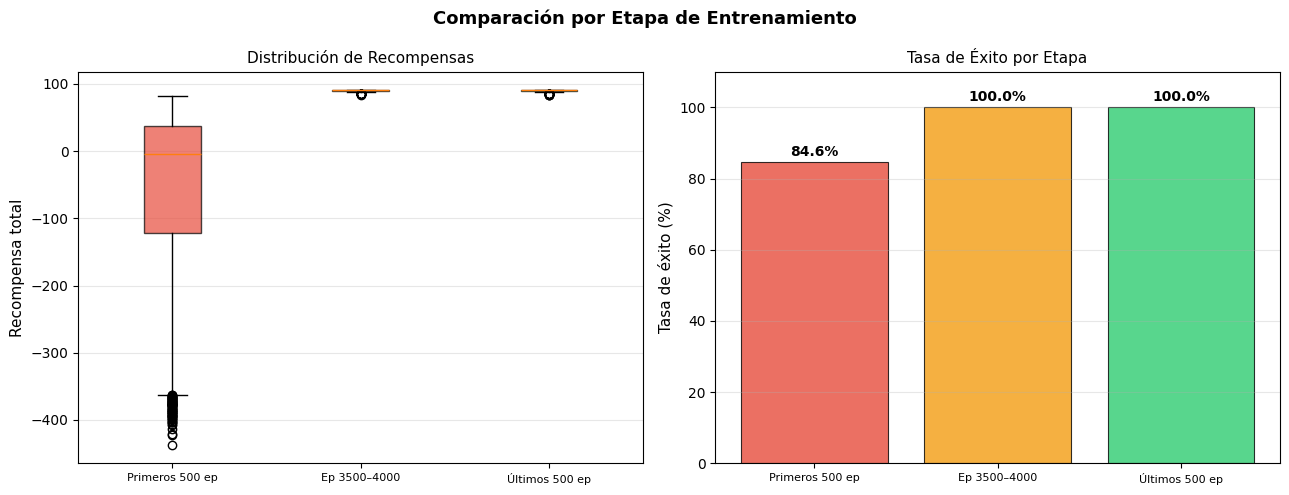

Guardado: stage_comparison.png


In [13]:
checkpoints = {
    "Primeros 500 ep":  (episode_rewards[:500],     success_flags[:500]),
    "Ep 3500\u20134000":   (episode_rewards[3500:4000], success_flags[3500:4000]),
    "\u00daltimos 500 ep":   (episode_rewards[-500:],    success_flags[-500:]),
}

labels  = list(checkpoints.keys())
rewards = [checkpoints[k][0] for k in labels]
success = [np.mean(checkpoints[k][1]) * 100 for k in labels]
colors  = ["#e74c3c", "#f39c12", "#2ecc71"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Comparaci\u00f3n por Etapa de Entrenamiento", fontsize=13, fontweight="bold")

bp = ax1.boxplot(rewards, labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel("Recompensa total", fontsize=11)
ax1.set_title("Distribuci\u00f3n de Recompensas", fontsize=11)
ax1.tick_params(axis="x", labelsize=8)
ax1.grid(True, alpha=0.3, axis="y")

bars = ax2.bar(labels, success, color=colors, alpha=0.8, edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, success):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("Tasa de \u00e9xito (%)", fontsize=11)
ax2.set_title("Tasa de \u00c9xito por Etapa", fontsize=11)
ax2.set_ylim(0, 110)
ax2.tick_params(axis="x", labelsize=8)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("stage_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: stage_comparison.png")


## 10. Resumen Final Q-Learning

In [14]:
print("\n" + "=" * 60)
print("               RESUMEN FINAL DEL EXPERIMENTO")
print("=" * 60)
print(f"  Entorno              : GridWorld3D {env.W}x{env.H}x{env.D}")
print(f"  Total de celdas      : {env.n_states}")
print(f"  Obstáculos           : {env.obstacle_count} ({env.obstacle_count/env.n_states*100:.1f}%)")
print(f"  Algoritmo            : Q-Learning (off-policy TD)")
print(f"  Episodios            : {N_EPISODES}")
print(f"  Alpha (α)            : {ALPHA}")
print(f"  Gamma (γ)            : {GAMMA}")
print(f"  Epsilon final        : {agent.epsilon:.4f}")
print("-" * 60)
print(f"  Estados en Q-table   : {agent.n_states_visited} / {env.n_states}")
print(f"  Cobertura del espacio: {agent.n_states_visited/env.n_states*100:.1f}%")
print("-" * 60)
print(f"  Tasa de éxito (eval) : {results['success_rate']:.1f}%")
print(f"  Pasos promedio       : {results['avg_steps']:.1f}")
print(f"  Recompensa media     : {results['avg_reward']:.2f}")
if results["best_path"]:
    path = results["best_path"]
    print(f"  Mejor camino         : {len(path)} pasos")
    floors = [p[2] for p in path]
    transitions = [(i, floors[i], floors[i+1]) for i in range(len(floors)-1) if floors[i] != floors[i+1]]
    if transitions:
        print(f"  Cambios de piso      : {len(transitions)}")
        for step_i, f_from, f_to in transitions:
            direction = "sube" if f_to > f_from else "baja"
            print(f"    Paso {step_i:>3}: Piso {f_from} → Piso {f_to} ({direction})")
print("=" * 60)


               RESUMEN FINAL DEL EXPERIMENTO
  Entorno              : GridWorld3D 8x8x8
  Total de celdas      : 512
  Obstáculos           : 102 (19.9%)
  Algoritmo            : Q-Learning (off-policy TD)
  Episodios            : 8000
  Alpha (α)            : 0.2
  Gamma (γ)            : 0.99
  Epsilon final        : 0.0500
------------------------------------------------------------
  Estados en Q-table   : 409 / 512
  Cobertura del espacio: 79.9%
------------------------------------------------------------
  Tasa de éxito (eval) : 100.0%
  Pasos promedio       : 18.0
  Recompensa media     : 91.50
  Mejor camino         : 19 pasos
  Cambios de piso      : 4
    Paso   1: Piso 0 → Piso 1 (sube)
    Paso   5: Piso 1 → Piso 2 (sube)
    Paso  11: Piso 2 → Piso 3 (sube)
    Paso  13: Piso 3 → Piso 4 (sube)


# Deep Q-Network


Para comparar Q-Learning tabular en estecaso, en un grid 3d pequeño no hay mucha diferencia pero en entornos reales el espacio de estados puede ser millones. DQN reemplaza la Q-table por una **red neuronal** que aproxima la función Q(s,a).

### Diferencias clave con Q-Learning tabular

| Aspecto | Q-Learning | DQN |
|---|---|---|
| Representación Q | Tabla exacta | Red neuronal (MLP) |
| Actualización | Por transición individual | Por mini-batch de replay |
| Estabilidad | Siempre estable | Requiere target network + replay |
| Generalización | Ninguna (por estado) | Interpola entre estados no vistos |

### Componentes de DQN (Mnih et al., 2015)

1. **Q-Network**: MLP que recibe el estado normalizado y produce Q(s,a) para cada acción
2. **Replay Buffer**: Almacena transiciones `(s, a, r, s', done)` y muestrea mini-batches aleatorios para romper correlaciones temporales
3. **Target Network**: Copia de Q-Network actualizada periódicamente; estabiliza los targets de entrenamiento

### Regla de actualización

$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(r + \gamma \max_{a'} Q_{\theta^-}(s', a') - Q_\theta(s, a)\right)^2\right]$$

Donde $\theta^-$ son los parámetros de la **target network** (fijos durante la actualización).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random as pyrandom


DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

Device: cpu


### Q-Network y Replay Buffer

El estado `(x, y, z)` se normaliza a `[0, 1]` antes de entrar a la red. La arquitectura es un MLP de dos capas ocultas con activaciones ReLU.

In [16]:
class QNetwork(nn.Module):
    """MLP que aproxima Q(s, a) para todas las acciones simultáneamente."""

    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ReplayBuffer:
    """Circular buffer that stores transitions and yields random mini-batches."""

    def __init__(self, capacity: int):
        self._buf = deque(maxlen=capacity)

    def push(self, state, action: int, reward: float, next_state, done: bool):
        self._buf.append((state, action, reward, next_state, float(done)))

    def sample(self, batch_size: int):
        batch = pyrandom.sample(self._buf, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            torch.FloatTensor(s),
            torch.LongTensor(a),
            torch.FloatTensor(r),
            torch.FloatTensor(ns),
            torch.FloatTensor(d),
        )

    def __len__(self) -> int:
        return len(self._buf)

### Agente DQN

In [ ]:
class DQNAgent:
    """
    DQN agent with experience replay and a periodically-updated target network.
    State is normalized to [0,1]^3 before being fed to the Q-Network.
    """

    def __init__(
        self,
        env: GridWorld3D,
        lr: float = 1e-3,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_min: float = 0.05,
        epsilon_decay: float = 0.001,
        buffer_capacity: int = 20_000,
        batch_size: int = 64,
        target_update_freq: int = 50,   # episodes between target net syncs
        hidden: int = 128,
    ):
        self.env             = env
        self.n_actions       = env.action_space.n
        self.gamma           = gamma
        self.epsilon         = epsilon_start
        self.epsilon_min     = epsilon_min
        self._decay_rate     = 1.0 - epsilon_decay
        self.batch_size      = batch_size
        self.target_update_freq = target_update_freq
        self._episode        = 0

        state_dim = 3  # normalized (x, y, z)
        self.q_net      = QNetwork(state_dim, self.n_actions, hidden).to(DEVICE)
        self.target_net = QNetwork(state_dim, self.n_actions, hidden).to(DEVICE)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.criterion = nn.SmoothL1Loss()  
        self.buffer    = ReplayBuffer(buffer_capacity)

        self.epsilon_history: list[float] = []
        self.loss_history:    list[float] = []

    # ------------------------------------------------------------------

    def _normalize(self, state: tuple) -> list:
        x, y, z = state
        return [
            x / max(self.env.W - 1, 1),
            y / max(self.env.H - 1, 1),
            z / max(self.env.D - 1, 1),
        ]

    def _state_tensor(self, state: tuple) -> torch.Tensor:
        return torch.FloatTensor(self._normalize(state)).unsqueeze(0).to(DEVICE)

    def select_action(self, state: tuple) -> int:
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            return int(self.q_net(self._state_tensor(state)).argmax().item())

    def greedy_action(self, state: tuple) -> int:
        with torch.no_grad():
            return int(self.q_net(self._state_tensor(state)).argmax().item())

    def push(self, state, action, reward, next_state, done):
        self.buffer.push(
            self._normalize(state), action, reward,
            self._normalize(next_state), done,
        )

    def train_step(self) -> Optional[float]:
        if len(self.buffer) < self.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        states      = states.to(DEVICE)
        actions     = actions.to(DEVICE)
        rewards     = rewards.to(DEVICE)
        next_states = next_states.to(DEVICE)
        dones       = dones.to(DEVICE)

        q_vals  = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q  = self.target_net(next_states).max(1)[0]
            targets = rewards + self.gamma * next_q * (1 - dones)

        loss = self.criterion(q_vals, targets)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()
        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self._decay_rate)
        self.epsilon_history.append(self.epsilon)
        self._episode += 1
        if self._episode % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

    @property
    def n_params(self) -> int:
        return sum(p.numel() for p in self.q_net.parameters())

## 1. Entrenamiento DQN

Se usa el **mismo entorno** que Q-Learning para comparación directa.

| Parámetro | Valor | Descripción |
|---|---|---|
| `lr` | 1e-3 | Tasa de aprendizaje Adam |
| `batch_size` | 64 | Tamaño del mini-batch de replay |
| `buffer_capacity` | 20 000 | Capacidad del replay buffer |
| `target_update_freq` | 50 | Episodios entre sincronizaciones de target net |
| `hidden` | 128 | Neuronas por capa oculta |
| `epsilon_decay` | 0.001 | Mismo schedule que Q-Learning |

In [ ]:
DQN_LR           = 1e-3
DQN_BATCH        = 64
DQN_BUFFER       = 20_000
DQN_TARGET_FREQ  = 50
DQN_HIDDEN       = 128
DQN_EPISODES     = 8000
TRAIN_EVERY      = 4   

env_dqn = GridWorld3D(
    width=6, height=6, depth=3,
    start=(0, 0, 0), goal=(5, 5, 2),
    obstacle_density=0.10,
    shaping_scale=0.5,
    max_steps=300,
    seed=SEED,
)

dqn_agent = DQNAgent(
    env=env_dqn,
    lr=DQN_LR,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
    buffer_capacity=DQN_BUFFER,
    batch_size=DQN_BATCH,
    target_update_freq=DQN_TARGET_FREQ,
    hidden=DQN_HIDDEN,
)

print(f"Q-Network params : {dqn_agent.n_params}")
print(f"Device           : {DEVICE}")
print(f"Camino alcanzable: {env_dqn._bfs_connected(env_dqn.start, env_dqn.goal)}\n")

dqn_rewards: list[float] = []
dqn_lengths: list[int]   = []
dqn_success: list[bool]  = []
dqn_losses:  list[float] = []

global_step = 0

for episode in range(1, DQN_EPISODES + 1):
    obs, _ = env_dqn.reset()
    state  = env_dqn.state_to_tuple(obs)
    total_reward = 0.0
    ep_losses    = []
    step = 0

    for step in range(env_dqn.max_steps):
        action = dqn_agent.select_action(state)
        obs_next, reward, terminated, truncated, info = env_dqn.step(action)
        next_state = env_dqn.state_to_tuple(obs_next)

        dqn_agent.push(state, action, reward, next_state, terminated or truncated)

        global_step += 1
        if global_step % TRAIN_EVERY == 0:
            loss = dqn_agent.train_step()
            if loss is not None:
                ep_losses.append(loss)

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    dqn_agent.decay_epsilon()
    dqn_rewards.append(total_reward)
    dqn_lengths.append(step + 1)
    dqn_success.append(info["reached_goal"])
    if ep_losses:
        dqn_losses.append(np.mean(ep_losses))

    if episode % LOG_EVERY == 0:
        w = 500
        avg_r  = np.mean(dqn_rewards[-w:])
        succ_r = np.mean(dqn_success[-w:]) * 100
        avg_l  = np.mean(dqn_losses[-w:]) if dqn_losses else float("nan")
        print(
            f"Ep {episode:>5} | ε={dqn_agent.epsilon:.4f} | "
            f"Reward ({w} ep): {avg_r:>7.2f} | "
            f"Éxito: {succ_r:>5.1f}% | "
            f"Loss: {avg_l:.4f}"
        )

print(f"\nDQN entrenamiento finalizado.")
print(f"Tasa de éxito final (últimos 500 ep): {np.mean(dqn_success[-500:]) * 100:.1f}%")

Q-Network params : 17798
Device           : cpu
Camino alcanzable: True

Ep  1000 | ε=0.3677 | Reward (500 ep):   69.52 | Éxito: 100.0% | Loss: 3.4225
Ep  2000 | ε=0.1352 | Reward (500 ep): -305.79 | Éxito:   4.6% | Loss: 0.4218
Ep  3000 | ε=0.0500 | Reward (500 ep):  -46.01 | Éxito:  73.0% | Loss: 0.2630
Ep  4000 | ε=0.0500 | Reward (500 ep):   93.67 | Éxito: 100.0% | Loss: 0.0808
Ep  5000 | ε=0.0500 | Reward (500 ep):   93.42 | Éxito: 100.0% | Loss: 0.0212
Ep  6000 | ε=0.0500 | Reward (500 ep):   93.76 | Éxito: 100.0% | Loss: 0.0132
Ep  7000 | ε=0.0500 | Reward (500 ep):   93.63 | Éxito: 100.0% | Loss: 0.0097
Ep  8000 | ε=0.0500 | Reward (500 ep):   93.68 | Éxito: 100.0% | Loss: 0.0091

DQN entrenamiento finalizado.
Tasa de éxito final (últimos 500 ep): 100.0%


## 2. Convergencia DQN

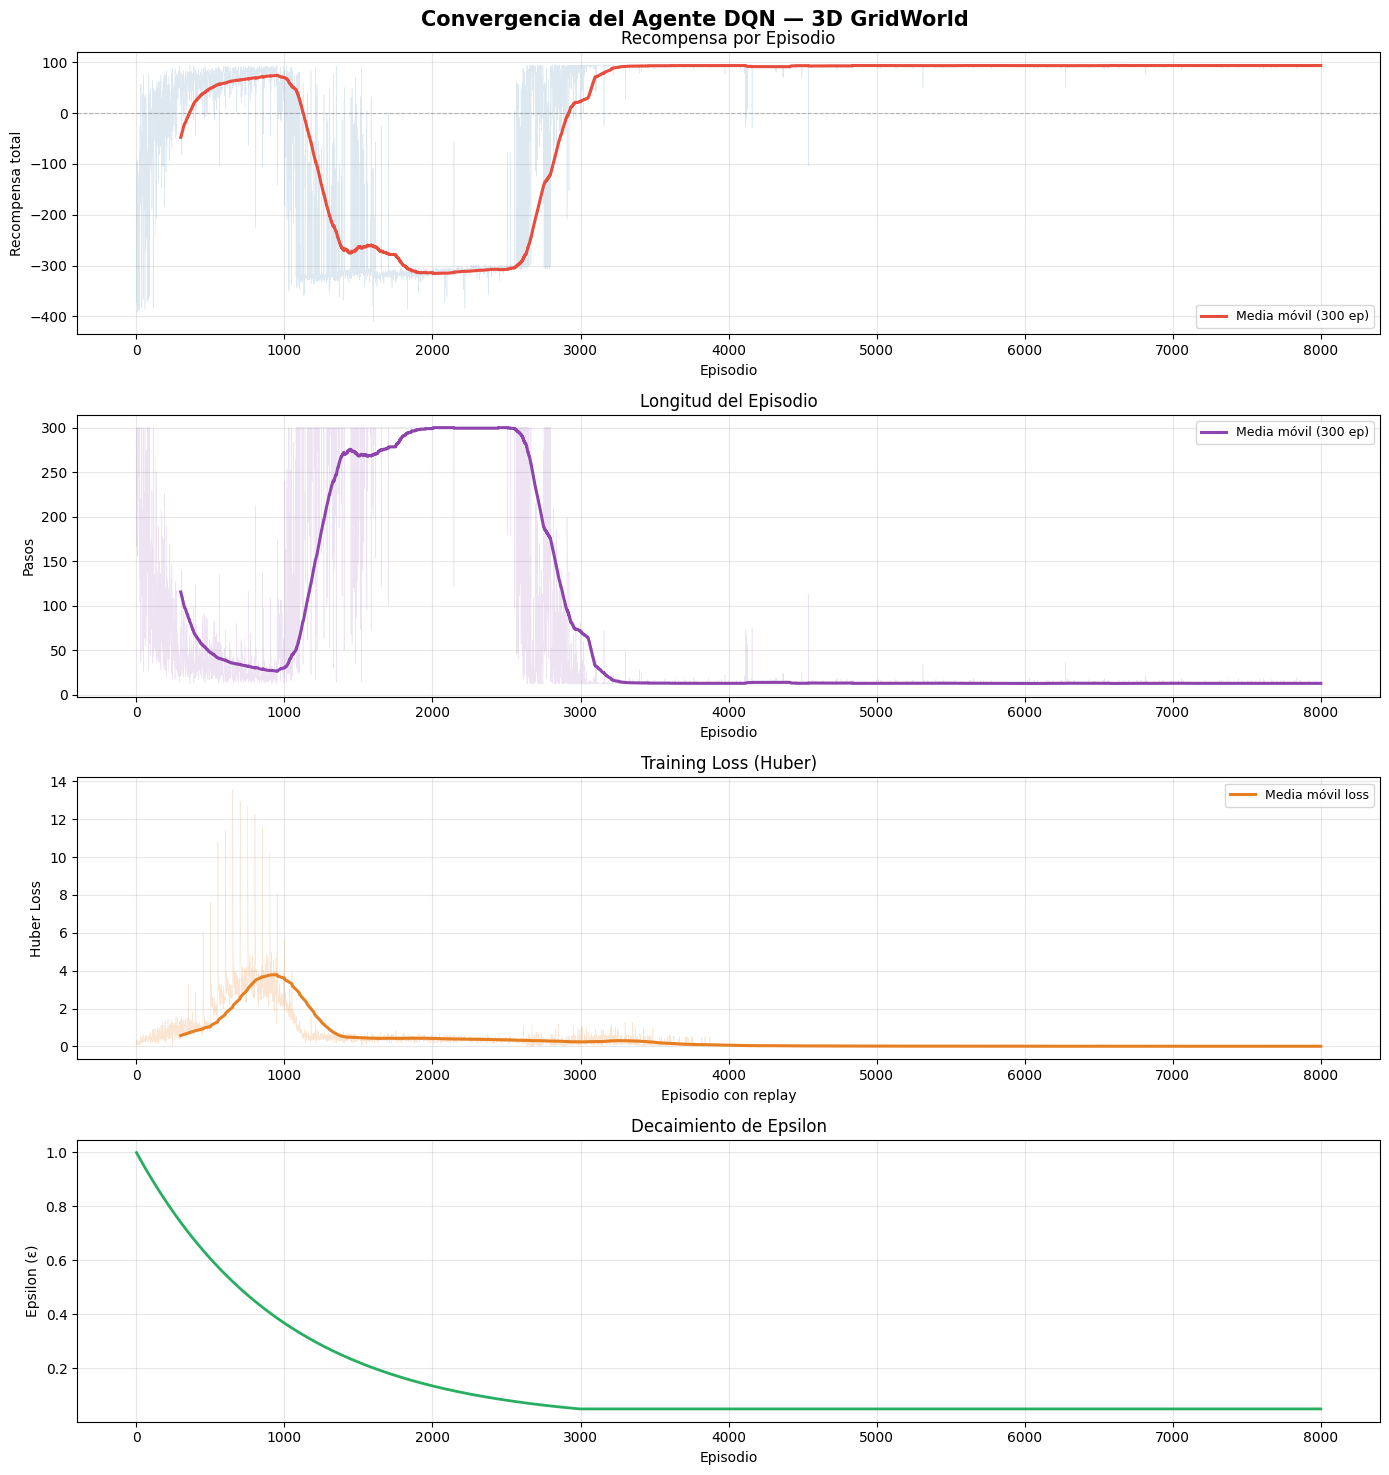

Guardado: dqn_convergence.png


In [19]:
WINDOW_DQN = 300
ep_axis    = np.arange(1, DQN_EPISODES + 1)
ma_dqn_r   = moving_average(dqn_rewards,  WINDOW_DQN)
ma_dqn_l   = moving_average(dqn_lengths,  WINDOW_DQN)
ma_axis_dqn = np.arange(WINDOW_DQN, DQN_EPISODES + 1)

n_loss = len(dqn_losses)
ma_loss = moving_average(dqn_losses, min(WINDOW_DQN, n_loss // 2 or 1))

fig, axes = plt.subplots(4, 1, figsize=(14, 15), sharex=False)
fig.suptitle("Convergencia del Agente DQN — 3D GridWorld", fontsize=15, fontweight="bold")

# Reward
ax = axes[0]
ax.plot(ep_axis, dqn_rewards, alpha=0.18, color="steelblue", linewidth=0.4)
ax.plot(ma_axis_dqn, ma_dqn_r, color="#e74c3c", linewidth=2.2, label=f"Media móvil ({WINDOW_DQN} ep)")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Recompensa total"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_title("Recompensa por Episodio"); ax.set_xlabel("Episodio")

# Episode length
ax = axes[1]
ax.plot(ep_axis, dqn_lengths, alpha=0.15, color="#8e44ad", linewidth=0.4)
ax.plot(ma_axis_dqn, ma_dqn_l, color="#8e44ad", linewidth=2.2, label=f"Media móvil ({WINDOW_DQN} ep)")
ax.set_ylabel("Pasos"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_title("Longitud del Episodio"); ax.set_xlabel("Episodio")

# Training loss
ax = axes[2]
loss_axis = np.arange(1, n_loss + 1)
ma_l_axis = np.arange(len(ma_loss) + 1, n_loss + 1) if len(ma_loss) < n_loss else np.arange(min(WINDOW_DQN, n_loss//2 or 1), n_loss + 1)
ax.plot(loss_axis, dqn_losses, alpha=0.2, color="#e67e22", linewidth=0.4)
if len(ma_loss) > 0:
    ax.plot(np.arange(len(ma_loss)) + (n_loss - len(ma_loss)) + 1, ma_loss,
            color="#e67e22", linewidth=2.2, label="Media móvil loss")
ax.set_ylabel("Huber Loss"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_title("Training Loss (Huber)"); ax.set_xlabel("Episodio con replay")

# Epsilon
ax = axes[3]
ax.plot(ep_axis, dqn_agent.epsilon_history, color="#27ae60", linewidth=2.0)
ax.set_ylabel("Epsilon (ε)"); ax.grid(True, alpha=0.3)
ax.set_title("Decaimiento de Epsilon"); ax.set_xlabel("Episodio")

plt.tight_layout()
plt.savefig("dqn_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: dqn_convergence.png")

## 3. Evaluación DQN

        EVALUACIÓN DQN — POLÍTICA GREEDY (50 eps)
  Tasa de éxito   : 100.0%
  Pasos promedio  : 12.0
  Recompensa media: 94.50
  Mejor recompensa: 94.50
  Longitud camino : 13 pasos


/var/folders/bf/p7_3d4ln30l_vsv0f_41b4sw0000gn/T/ipykernel_5900/416895561.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


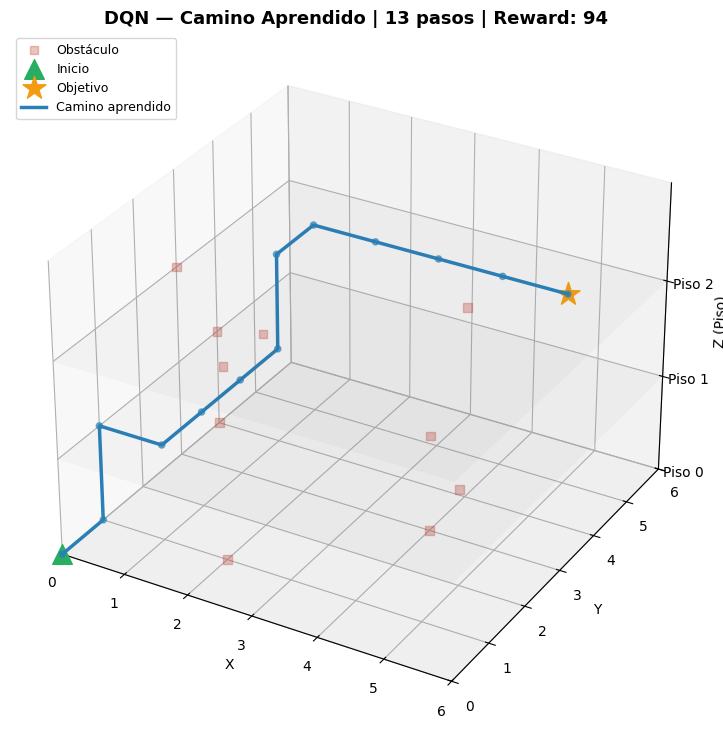

In [20]:
def evaluate_dqn(env: GridWorld3D, agent: DQNAgent, n_eval: int = 50) -> dict:
    """Run greedy DQN episodes and collect stats + best path."""
    successes, steps_list, reward_list = [], [], []
    best_path, best_reward = None, -np.inf

    for _ in range(n_eval):
        obs, _ = env.reset()
        state  = env.state_to_tuple(obs)
        path   = [env.start]
        total_reward = 0.0
        done, step = False, 0

        while not done and step < env.max_steps:
            action = agent.greedy_action(state)
            obs, reward, terminated, truncated, info = env.step(action)
            state = env.state_to_tuple(obs)
            path.append(env.get_state())
            total_reward += reward
            done = terminated or truncated
            step += 1

        successes.append(info["reached_goal"])
        steps_list.append(step)
        reward_list.append(total_reward)
        if info["reached_goal"] and total_reward > best_reward:
            best_reward, best_path = total_reward, path

    return {
        "success_rate": np.mean(successes) * 100,
        "avg_steps":    np.mean(steps_list),
        "avg_reward":   np.mean(reward_list),
        "best_path":    best_path,
        "best_reward":  best_reward,
    }


dqn_results = evaluate_dqn(env_dqn, dqn_agent, n_eval=50)

print("=" * 52)
print("        EVALUACIÓN DQN — POLÍTICA GREEDY (50 eps)")
print("=" * 52)
print(f"  Tasa de éxito   : {dqn_results['success_rate']:.1f}%")
print(f"  Pasos promedio  : {dqn_results['avg_steps']:.1f}")
print(f"  Recompensa media: {dqn_results['avg_reward']:.2f}")
if dqn_results['best_path']:
    print(f"  Mejor recompensa: {dqn_results['best_reward']:.2f}")
    print(f"  Longitud camino : {len(dqn_results['best_path'])} pasos")
print("=" * 52)

if dqn_results["best_path"]:
    plot_world(
        env_dqn,
        path=dqn_results["best_path"],
        title=f"DQN — Camino Aprendido | {len(dqn_results['best_path'])} pasos | Reward: {dqn_results['best_reward']:.0f}",
    )

## 4. Comparación Q-Learning vs DQN

Comparamos ambos algoritmos sobre el **mismo entorno** con los mismos hiperparámetros de exploración.

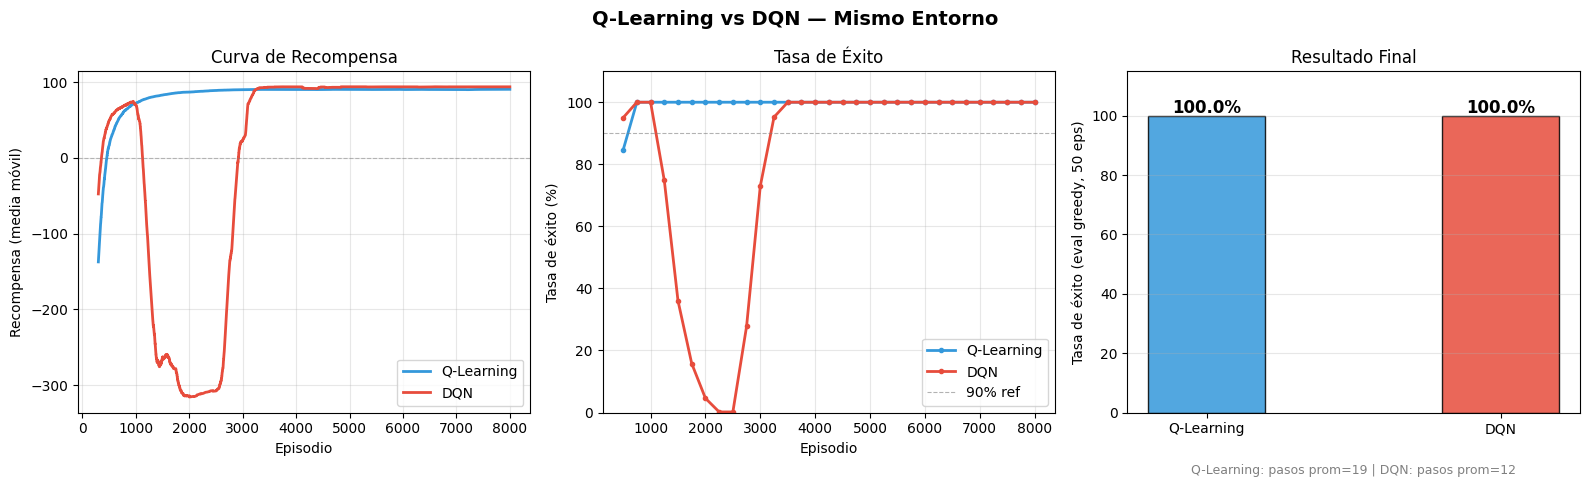

Guardado: ql_vs_dqn.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Q-Learning vs DQN — Mismo Entorno", fontsize=14, fontweight="bold")

# ── Reward curves ─────────────────────────────────────────────────────
ax = axes[0]
ma_ql = moving_average(episode_rewards, WINDOW_DQN)
ma_dq = moving_average(dqn_rewards,     WINDOW_DQN)
ma_x  = np.arange(WINDOW_DQN, min(N_EPISODES, DQN_EPISODES) + 1)
ax.plot(ma_x, ma_ql[:len(ma_x)], color="#3498db", linewidth=2, label="Q-Learning")
ax.plot(ma_x, ma_dq[:len(ma_x)], color="#e74c3c", linewidth=2, label="DQN")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Episodio"); ax.set_ylabel("Recompensa (media móvil)")
ax.set_title("Curva de Recompensa"); ax.legend(); ax.grid(True, alpha=0.3)

# ── Success rate bars ─────────────────────────────────────────────────
ax = axes[1]
window_cmp = 500
sr_ql = [np.mean(success_flags[i:i+window_cmp])*100 for i in range(0, N_EPISODES-window_cmp+1, window_cmp//2)]
sr_dq = [np.mean(dqn_success[i:i+window_cmp])*100  for i in range(0, DQN_EPISODES-window_cmp+1, window_cmp//2)]
x_ql  = np.arange(len(sr_ql)) * (window_cmp//2) + window_cmp
x_dq  = np.arange(len(sr_dq)) * (window_cmp//2) + window_cmp
ax.plot(x_ql, sr_ql, color="#3498db", linewidth=2, marker="o", markersize=3, label="Q-Learning")
ax.plot(x_dq, sr_dq, color="#e74c3c", linewidth=2, marker="o", markersize=3, label="DQN")
ax.axhline(90, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="90% ref")
ax.set_xlabel("Episodio"); ax.set_ylabel("Tasa de éxito (%)")
ax.set_title("Tasa de Éxito"); ax.set_ylim(0, 110); ax.legend(); ax.grid(True, alpha=0.3)

# ── Final eval bar chart ──────────────────────────────────────────────
ax = axes[2]
ql_eval = np.mean(success_flags[-500:]) * 100
dq_eval = dqn_results["success_rate"]
bars = ax.bar(["Q-Learning", "DQN"], [ql_eval, dq_eval],
              color=["#3498db", "#e74c3c"], alpha=0.85, edgecolor="black", width=0.4)
for bar, val in zip(bars, [ql_eval, dq_eval]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Tasa de éxito (eval greedy, 50 eps)")
ax.set_title("Resultado Final"); ax.set_ylim(0, 115); ax.grid(True, alpha=0.3, axis="y")

# Summary text
ql_steps = np.mean([l for l, s in zip(episode_lengths[-500:], success_flags[-500:]) if s] or [300])
dq_steps = dqn_results["avg_steps"]
ax.text(0.5, -0.18,
        f"Q-Learning: pasos prom={ql_steps:.0f} | DQN: pasos prom={dq_steps:.0f}",
        transform=ax.transAxes, ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("ql_vs_dqn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: ql_vs_dqn.png")